In [1]:
# Show current directory
import os
curr_dir = os.getcwd()
print(curr_dir)
import json
# Define general variables
# parent = r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\CNN_TRAINING_SESSIONS" # Modify this to your data path folder
parent=r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\Dataset_from_paper" 

### HOME PC
# parent=r"E:\neurospark_mat\CNN_TRAINING_SESSIONS"


c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch


In [2]:
# Add parent directory to path (To acess sntt_utils)
import sys

parent_dir = os.path.abspath(os.path.join(curr_dir, os.pardir))
liset_path = os.path.abspath(os.path.join(curr_dir, '../liset_tk'))


# Add the grandparent directory to the system path
# grandparent_dir = os.path.abspath(os.path.join(current_dir, os.pardir, os.pardir))
sys.path.append(parent_dir)
sys.path.append(liset_path)
# from liset_tk import liset_tk
from liset_paper import liset_paper as liset_tk

from liset_aux import ripples_std, middle
from signal_aid import most_active_channel, bandpass_filter

print(sys.path)


['c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples\\utils', 'c:\\nrn\\lib\\python', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\python39.zip', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\DLLs', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\lib', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples', '', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32\\lib', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\Pythonwin', 'c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples', 'c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples\\liset_tk']


In [3]:
import torch
import numpy as np

# Check CUDA Installation
print(torch.cuda.is_available())

# Get the number of available GPUs
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs: {num_gpus}")

# Get information about each GPU
for i in range(num_gpus):
    device_props = torch.cuda.get_device_properties(i)
    print(f"\nGPU {i}:")
    print(f"  Name: {device_props.name}")
    print(f"  Total memory: {device_props.total_memory / 1024**3:.2f} GB")
    print(f"  Multiprocessor count: {device_props.multi_processor_count}")
    print(f"  Major compute capability: {device_props.major}")
    print(f"  Minor compute capability: {device_props.minor}")

False
Number of GPUs: 0


In [4]:
# Set the device to be used
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")     # torch.device("cpu") #

print("device: ", device)

device:  cpu


In [5]:
dt=1  # Time step in milliseconds (1 ms)


RIPPLE_DETECTION_OFFSET = [18, 45, 31, 20] # it's calculated as 4.5 periods of the ripple wavelet - for 100 Hz and 250 Hz as the limit frequencies
# The Windows for HFO detection are based on the MAX DETECTION OFFSET

#TODO - Why are these values? Can I tune them in a better way?
RIPPLE_CONFIDENCE_WINDOW = int(round(RIPPLE_DETECTION_OFFSET[1] * 1.8)) 

# in timesteps (ms) - Max time from the Insertion Timing to the GT annotation
MAX_DETECTION_OFFSET = RIPPLE_DETECTION_OFFSET[1]   # in timesteps (ms)

MEAN_DETECTION_OFFSET = RIPPLE_DETECTION_OFFSET[2]   # in timesteps (ms)

WINDOW_SIZE = int(RIPPLE_DETECTION_OFFSET[1]*4)   # in timesteps (ms) - The size of the window to slice the input data

# unit: timesteps (ms) - The number of steps that 2 consecutive windows must overlap to not lose any relevant CBs
# std, mean = ripples_std(parent) # 61 ms # in seconds
# INTERSECT_WINDOW_LEN=int((std+mean)*1000) # in timesteps (ms) - The size of the intersection window to slice the input data
INTERSECT_WINDOW_LEN = 60  # in timesteps (ms) - The size of the intersection window to slice the input data

# unit: timesteps (ms) - The number of steps that the window must shift to get the next window
WINDOW_SHIFT = int(WINDOW_SIZE - INTERSECT_WINDOW_LEN)

# unit: timesteps (ms) - The time window after the GT annotation where the network should predict the burst (GT_time, GT_time + PRED_CAUSALITY_WINDOW)
# This is needed to give the network some extra time steps to increase the membrane potential and spike
PRED_CAUSALITY_WINDOW = int(5)     # Giving PRED_CAUSALITY_WINDOW ms for the network to update its inner state and spike   

# unit: timesteps (ms) - The time window around the GT annotation where the network should predict the burst (GT_time - PRED_GT_TOLERANCE, GT_time + PRED_GT_TOLERANCE)
PRED_GT_TOLERANCE = int(RIPPLE_DETECTION_OFFSET[3])  # in timesteps (ms)
print(f"WINDOW_SIZE: {WINDOW_SIZE}")
print(f"INTERSECT_WINDOW_LEN: {INTERSECT_WINDOW_LEN}")
print(f"WINDOW_SHIFT: {WINDOW_SHIFT}")
print(f"MEAN DETECTION OFFSET: {MEAN_DETECTION_OFFSET}")
print(f"PRED_GT_TOLERANCE: {PRED_GT_TOLERANCE}")
print(f"PRED_CAUSALITY_WINDOW: {PRED_CAUSALITY_WINDOW}")

WINDOW_SIZE: 180
INTERSECT_WINDOW_LEN: 60
WINDOW_SHIFT: 120
MEAN DETECTION OFFSET: 31
PRED_GT_TOLERANCE: 20
PRED_CAUSALITY_WINDOW: 5


In [6]:
from torch.utils.data import TensorDataset, DataLoader

save_load_path = os.path.join(curr_dir, "train_test_data")
load_data=True
id=1
if load_data:
    print("Loading training and test tensors from disk...")
    train_data_tensor = torch.load(os.path.join(save_load_path,f"train_data_{id}.pt"))
    train_gt_tensor = torch.load(os.path.join(save_load_path,f"train_labels_{id}.pt"))
    test_data_tensor = torch.load(os.path.join(save_load_path,f"test_data_{id}.pt"))
    test_gt_tensor = torch.load(os.path.join(save_load_path,f"test_labels_{id}.pt"))

Loading training and test tensors from disk...


In [7]:
# Create a Tensor Dataset
train_dataset = TensorDataset(train_data_tensor, train_gt_tensor)
test_dataset = TensorDataset(test_data_tensor, test_gt_tensor)

# Define the batch size
batch_size = 256#64 #32 # 2

# Create Data Loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,   # Do we want to force training one by one, i.e., batch_size=1?
    shuffle=True,   # TODO: We are shuffling because each window resets the state of the network so it should not matter. Might not be the case for RNNs!!
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

In [8]:

# Show how many batches are in the training and testing data
print("Number of Training Batches: ", len(train_loader))
print("Number of Testing Batches: ", len(test_loader))

Number of Training Batches:  91
Number of Testing Batches:  16


In [9]:
print(f"Sorted GT Distribution: {np.unique(test_gt_tensor, return_counts=True)}")


Sorted GT Distribution: (array([ -1.,  31.,  32.,  33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,
        41.,  42.,  43.,  44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,
        52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,
        63.,  64.,  65.,  66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,
        74.,  75.,  76.,  77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,
        85.,  86.,  87.,  88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,
        96.,  97.,  98.,  99., 100., 101., 102., 103., 104., 105., 106.,
       107., 108., 109., 110., 111., 112., 113., 114., 115., 116., 117.,
       118., 119., 120., 121., 122., 123., 124., 125., 126., 127., 128.,
       129., 130., 131., 132., 133., 134., 135., 136., 137., 138., 139.,
       140., 141., 142., 143., 144., 145., 146., 147., 148., 149., 150.,
       151., 152., 153., 154., 155., 156., 157., 158., 159., 160., 161.,
       162., 163., 164., 165., 166.], dtype=float32), array([1018,   12,   24,   15,   34,   27,   

## Define the Network

### Define the Loss Function

In [10]:
from snntorch import functional as SF
from snnTorch.utils.loss import mse_temporal_loss_penalty, first_spike_acc
from snnTorch.utils.my_loss import mse_temporal_loss_penaltyfn_fp
'''
Define the loss function
Let's use the mse_temporal_loss - Mean Squared Error Loss Temporal Loss.

Forward function:
Parameters:
    - output: Predictions of the network - First spike time of each output neuron.
        shape: torch.Tensor shape=(batch_size, num_classes) 
    - target:  Ground truth of the network - First spike time of each output neuron.
        shape: torch.Tensor shape=(batch_size, num_timesteps)
Returns:
    - loss: The loss value 
        shape: torch.Tensor shape=()

The loss function calculates the MSE loss of the first spike time of each output neuron.
If the output neuron spikes within the tolerance window, the loss is 0.
If the output neuron does not spike -> Considers it to spike at the last timestep and calculates the loss accordingly.
Note: The spike time is divided by the number of timesteps to normalize it between 0 and 1 -> Loss gets pretty low values
'''
# PENALTY_FACTOR = 2    # 1.5  # 1    # Penalty factor for the loss function (Extreme cases)


# loss_fn = mse_temporal_loss_penalty(
#     # target_is_time=True -> Target is the spike time (time step) of each output neuron. If false, the target is the gt class and the spike time of each class is fixed
#     target_is_time=True,
#     tolerance=PRED_GT_TOLERANCE,       # Tolerance for the mse loss (in timesteps). If the output neuron spikes within this tolerance, the loss is 0
#     reduction='mean',        # Average the loss across the batch
#     penalty_factor=PENALTY_FACTOR,
#     normalize=False, # True      # Whether to normalize the loss by the number of timesteps 
# )

""" loss_fn = SF.mse_temporal_loss(
    target_is_time=True,
    tolerance=PRED_GT_TOLERANCE,       # Tolerance for the mse loss (in timesteps). If the output neuron spikes within this tolerance, the loss is 0
    reduction='mean'  # 'mean',          # Average the loss across the batch OR Sum the loss across the batch
) """

    
fn_penalty_factor=4 # Penalty factor for the false negative loss (if the output neuron does not spike when it should)
fp_penalty_factor=1 # Penalty factor for the false positive loss (if the output neuron spikes when it should not)

loss_fn = mse_temporal_loss_penaltyfn_fp(
    # target_is_time=True -> Target is the spike time (time step) of each output neuron. If false, the target is the gt class and the spike time of each class is fixed
    target_is_time=True,
    tolerance=PRED_GT_TOLERANCE,       # Tolerance for the mse loss (in timesteps). If the output neuron spikes within this tolerance, the loss is 0
    reduction='mean',        # Average the loss across the batch
    fn_penalty_factor=fn_penalty_factor,  # Penalty factor for the false negative loss (if the output neuron does not spike when it should)
    fp_penalty_factor=fp_penalty_factor,  # Penalty factor for the false positive loss (if the output neuron spikes when it should not)
    normalize=True, # True      # Whether to normalize the loss by the number of timesteps 
)



In [ ]:
import snntorch as snn
import torch.nn as nn
from snntorch import surrogate

# Global Parameters
v_thr = 1.0
placeholder_val = 0.5

# Define the surrogate gradient function to propagate spikes through the network
spike_grad = surrogate.fast_sigmoid()   # surrogate.atan()   

In [12]:
# Parameters for Dense Layers
inputDataDim = 2 # UP DN   # max_channel_idx - min_channel_idx + 1    # Number of input channels

input_to_hidden = (inputDataDim, 24) # 24 # 16 # TODO: Increase the size of this layer # (inputDataDim, 100) # (inputDataDim, 500)  # Number of neurons in the first Fully-Connected Layer

hiddenL2Dim = (input_to_hidden[1], input_to_hidden[1])  # Number of neurons in the Recurrent Fully-Connected Layer (L2)

hiddenL3Dim = (input_to_hidden[1], 16)  # 16 # Number of neurons in the Fully-Connected Layer (L3)

hiddenL4Dim = (hiddenL3Dim[1], input_to_hidden[1])  # Number of neurons in the Recurrent Fully-Connected Layer (L4)

hidden_to_out = (hiddenL3Dim[1], 1)  # Number of neurons in the Output Fully-Connected Layer
# In this case, we only need 1 output neuron -> Fires when HFO is detected

In [ ]:
# Define Network
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        
        # Create a Linear Layer to serve input to LIF1
        self.fc_in = nn.Linear(input_to_hidden[0], input_to_hidden[1],
                bias=False,
                dtype=torch.float32     # Set the data type of the weights to float32
        )

        # TODO: Should the LIF neurons be able to get a negative membrane potential? I think so?
        self.lif1 = snn.Synaptic(
            alpha=torch.full(size=(input_to_hidden[1],), fill_value=placeholder_val), 
            beta=torch.full(size=(input_to_hidden[1],), fill_value=placeholder_val),
            threshold=v_thr,
            reset_mechanism="zero", reset_delay=False,
            # TODO: How to add Refractory Period?
            # init_hidden=True,   # enables the methods in snntorch.backprop to automatically clear the hidden states and detach them from the comp. graph
            spike_grad=spike_grad,
            learn_alpha=True,   # Learn the alpha parameter
            learn_beta=True,    # Learn the beta parameter
            learn_threshold=False,   # Learn the threshold parameter
            
        )      

        """ self.fc2 = nn.Linear(
            hiddenL2Dim[0], hiddenL2Dim[1],
            bias=False,
            dtype=torch.float32     # Set the data type of the weights to float32
        ) """

        self.fc3 = nn.Linear(
            hiddenL3Dim[0], hiddenL3Dim[1],
            bias=False,
            dtype=torch.float32     # Set the data type of the weights to float32
        )

        self.lif2 = snn.Synaptic(
            alpha=torch.full(size=(hiddenL3Dim[1],), fill_value=placeholder_val), 
            beta=torch.full(size=(hiddenL3Dim[1],), fill_value=placeholder_val),
            threshold=v_thr,
            reset_mechanism="zero", reset_delay=False,
            # TODO: How to add Refractory Period?
            # init_hidden=True,   # enables the methods in snntorch.backprop to automatically clear the hidden states and detach them from the comp. graph
            spike_grad=spike_grad,
            learn_alpha=True,   # Learn the alpha parameter
            learn_beta=True,    # Learn the beta parameter
            learn_threshold=False,   # Learn the threshold parameter
        )   

        """ self.fc4 = nn.Linear(
            hiddenL4Dim[0], hiddenL4Dim[1],
            bias=False,
            dtype=torch.float32     # Set the data type of the weights to float32
        ) """

        self.fc_out = nn.Linear(
            hidden_to_out[0], hidden_to_out[1],
            bias=False,
            dtype=torch.float32     # Set the data type of the weights to float32
        )

        self.lif_out = snn.Synaptic(
            alpha=placeholder_val, 
            beta=placeholder_val,
            threshold=v_thr,
            reset_mechanism="zero", reset_delay=False,
            # init_hidden=True,   # enables the methods in snntorch.backprop to automatically clear the hidden states and detach them from the comp. graph
            spike_grad=spike_grad,
            learn_alpha=True,   # Learn the alpha parameter
            learn_beta=True,    # Learn the beta parameter
            learn_threshold=False,   # Learn the threshold parameter
        )

        # Initialize the membrane potential of each LIF neuron
        self.syn1, self.mem1, self.spk1 = None, None, None
        self.syn2, self.mem2, self.spk2 = None, None, None
        self.syn_out, self.mem_out, self.spk_out = None, None, None

    """
    Function called during the forward pass of the network
    """
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        '''
        Forward Pass of the Network (Single Step Update)

        Parameters:
        - x: input tensor. Shape: (batch_size, num_features)

        Returns:
        - spk_vals: tuple of tensors containing the spikes of the neurons. Shape: (batch_size, num_neurons)
        - mem_vals: tuple of tensors containing the membrane potentials of the neurons. Shape: (batch_size, num_neurons)
        - syn_vals: tuple of tensors containing the currents of the neurons. Shape: (batch_size, num_neurons)
        '''
        cur_batch_size, cur_num_channels = x.shape

        # --- Lazy State Initialization
        if self.mem1 is None:
            device = x.device   # Get the device of the input tensor

            # Initialize the membrane potential of each LIF neuron
            self.syn1, self.mem1 = self.lif1.reset_mem()
            self.syn2, self.mem2 = self.lif2.reset_mem()
            self.syn_out, self.mem_out = self.lif_out.reset_mem()

            # # Define small residual for spk1
            # spk1_factor = 0.01
            # self.spk1 = torch.rand(size=(cur_batch_size, input_to_hidden[1]), dtype=torch.float32, device=device) * spk1_factor
            # self.spk2 = torch.zeros(size=(cur_batch_size, hiddenL3Dim[1]), dtype=torch.float32, device=device) * spk1_factor
            # self.spk_out = torch.zeros(size=(cur_batch_size, hidden_to_out[1]), dtype=torch.float32, device=device)

        # 
        if len(x.shape) == 1:
            # If the input is 1D, it means we have only one feature (one channel)
            # Unsqueeze the input to add the num_features dimension
            x = x.unsqueeze(1)
            
        ############# State Update #############
        # Calculate Input Current for LIF1 from the Input Layer (FC1) Input -> LIF1
        cur_fc1 = self.fc_in(x) 
    
        # Calculate Input Current from Recurrent Layer (FC2) LIF1 -> LIF1
        # cur_fc2 = self.fc2(spk1)   # Connect LIF1 to itself using FC Layer 2 (Recurrent Layer)

        # Join the input currents for LIF1 (FC1 + FC2)
        cur1 = cur_fc1 # + cur_fc2  # TODO: Not feeding Recurent Layer to LIF1 for now

        # Feed the joined input current to LIF1
        self.spk1, self.syn1, self.mem1 = self.lif1(cur1, self.syn1, self.mem1)  # Feed input to LIF1

        # Calculate Input Current for LIF2 from LIF1 (FC3) LIF1 -> LIF2
        cur2 = self.fc3(self.spk1)   # Connect LIF1 to LIF2 using FC Layer 3
        # Feed the input current to LIF2 and get the spikes, synaptic currents and membrane potentials
        self.spk2, self.syn2, self.mem2 = self.lif2(cur2, self.syn2, self.mem2)  # Feed input to LIF2

        # Calculate Input Current for LIF_OUT from LIF2 (FC4) LIF2 -> LIF_OUT
        cur_out = self.fc_out(self.spk2)
        # Feed the input current to LIF_OUT and get the spikes, synaptic currents and membrane potentials
        self.spk_out, self.syn_out, self.mem_out = self.lif_out(cur_out, self.syn_out, self.mem_out)  # Feed input to LIF_OUT

        # Return the currents, membrane potentials and spikes of the current timestep
        syn_val = (self.syn1, self.syn2, self.syn_out)
        mem_vals = (self.mem1, self.mem2, self.mem_out)
        spk_vals = (self.spk1, self.spk2, self.spk_out)

        # TODO: Check if the dimensions are correct
        return (spk_vals, mem_vals, syn_val)

In [15]:
# Load the network onto CUDA if available
net = Net().to(device)

In [16]:
from typing import Optional
import copy
def forward_step(
        data: torch.Tensor, gt: torch.Tensor, 
        is_train: bool = True,
        verbose=False, print_params=False,
        print_first_spike_times=False,return_spikes=False,
    ) -> tuple[float, float, Optional[torch.Tensor]]:
    '''
    Perform a training step for the network

    Parameters:
    -----------
    data: torch.Tensor
        The input data for the network. Shape: (num_batches, num_steps).
    gt: torch.Tensor
        The ground truth for the network. Shape: (batch_size,).
        Since we are using a first-time-to-spike loss function, the ground truth is the time step of the first spike of the neuron. (or -1 if spiking on the last timestep)
    verbose: bool
        Whether to print debug information
    print_params: bool
        Whether to print the parameters of the network before the forward pass
    print_first_spike_times: bool
        Whether to print the first spike times

    Returns:
    --------
    Tuple (loss, accuracy).
    - loss: float
        The loss value for the current batch.
    - accuracy: float
        The accuracy value for the current batch.
    '''
    if is_train:
        net.train() # Set the network to training mode
    else:
        net.eval()  # Set the network to evaluation mode

    if print_params:
        # Show the Network State before the forward pass
        print("Network Parameters before Forward Pass")
        for idx, param in enumerate(net.parameters()):
            print(f"Layer {idx} Parameters Shape={param.shape} | Preview: {param}\n")

        print("=====================================\n")

    if verbose:
        # View the shape of the data
        # print(f"Data Shape: {data.shape} | Value={data[:10]}")
        print(f"Data Shape: {data.shape}")
        print(f"Number of Input Activations: {torch.sum(data)}")
        print(f"Targets Shape: {gt.shape} |  Value={gt.tolist()}")
        # print(f"Targets Shape: {gt.shape}")
        print("=====================================\n")

    # Feed a single batch of data through the network
    spikes, mem, cur = net(data)
    if verbose:
        # Print the shapes of the recorded spikes, membrane potentials and currents lists
        print(f"Number of Spike/Voltage/Current Recorded lists: ", len(spikes), len(mem), len(cur))
        print("=====================================\n")

    if verbose:
        # Show the Network State after the forward pass
        lif1_spikes, lif2_spikes, lif_out_spikes = spikes
        lif1_mem, lif2_mem, lif_out_mem = mem
        lif1_cur, lif2_cur, lif_out_cur = cur

        # Print the shapes of the recorded spikes, membrane potentials and currents
        print(f"Lif1 Spikes Shape: {lif1_spikes.shape} | Membrane Potentials Shape: {lif1_mem.shape} | Currents Shape: {lif1_cur.shape}")
        print(f"Lif2 Spikes Shape: {lif2_spikes.shape} | Membrane Potentials Shape: {lif2_mem.shape} | Currents Shape: {lif2_cur.shape}")
        print(f"Lif_Out Spikes Shape: {lif_out_spikes.shape} | Membrane Potentials Shape: {lif_out_mem.shape} | Currents Shape: {lif_out_cur.shape}")

        print(f"Number of spikes in LIF1: {torch.sum(lif1_spikes)}")
        print(f"Number of spikes in LIF2: {torch.sum(lif2_spikes)}")
        print(f"Number of spikes in LIF_OUT: {torch.sum(lif_out_spikes)}")
        print("=====================================\n")
    
    # ------ Loss and Accuracy Calculation ------
    out_spikes = spikes[-1]    # out_spikes shape = (num_steps, batch_size, num_neurons)

    # Add num_features dimension to the ground truth tensor
    gt = gt.unsqueeze(1)   # gt shape = (batch_size, 1)

    # Calculate the loss for the current Batch
    loss_val = loss_fn(out_spikes, gt.clone())   # Copy the ground truth to avoid modifying it in place

    # Scale the loss value to account for class imbalance
    """
    # This is a possible solution to the class imbalance problem. Does not seem to work well.
    scaled_loss = loss_val.clone()  # Create a copy of the loss value
    if gt.item() == 1:
        # Class 1 has 1/4 of the input windows of class 0
        # Scale the loss value by 4
        scaled_loss *= 4
    """

    # Calculate the Accuracy
    # There is no time tolerance for the accuracy calculation? -> The first spike time must be exactly the same?
    # acc = SF.accuracy_temporal(out_spikes, gt)
    acc = first_spike_acc(out_spikes, gt, tolerance=PRED_GT_TOLERANCE, verbose=False)

    if verbose or print_first_spike_times:
        # Find the first spike of each output neuron
        first_spikes = torch.argmax(out_spikes, dim=0)

        # If max spike value is 0 -> set the first spike to -1
        first_spikes[first_spikes == 0] = -1

        # Show the Output Spikes and Loss Value
        print(f"Output Spikes shape: {out_spikes.shape}. | First spike of each Output Neuron: {first_spikes}\n")
    if verbose:
        print(f"Loss val shape: {loss_val.shape} | Value: {loss_val.item()}")
        print(f"Accuracy Shape: {acc.shape} | Value: {acc.item()}")
        print("=====================================\n")

    # ------ Backward Pass (Gradient calculation and weight updates) ------
    if not is_train:
        if return_spikes:
            return loss_val.item(), acc.item(), out_spikes.detach()
        return loss_val.item(), acc.item()
    


In [17]:
# Load the Initial network from a file
LOAD_NETWORK = True
# TODO: Initial weights don't have to be loaded? Could just be random
prefix="dsb4updn_median_200_4f"
if LOAD_NETWORK:
    net.load_state_dict(torch.load(f"./out/{prefix}_trained_net_loss.pth"))

In [18]:
# Test the network on the entire test set

detection_window = MAX_DETECTION_OFFSET #+PRED_GT_TOLERANCE # Number of time steps allowed after GT
from utils.permutation_test import *
TP,FP,FN,TN,test_loss_hist,test_acc_hist,first_spike_times=evaluate_model(test_loader,net,forward_step,device,detection_window)


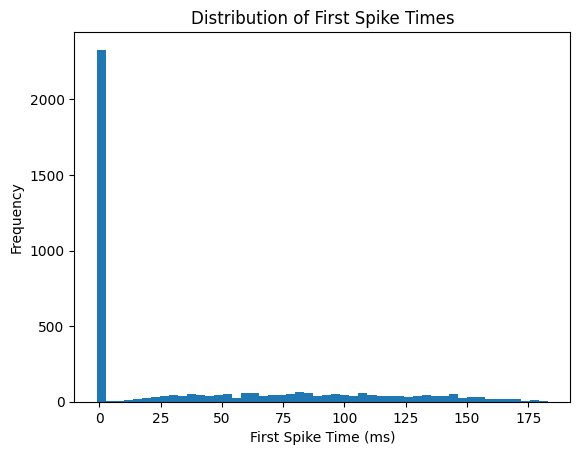

In [19]:
import matplotlib.pyplot as plt

plt.hist(first_spike_times, bins=50)
plt.xlabel("First Spike Time (ms)")
plt.ylabel("Frequency")
plt.title("Distribution of First Spike Times")
plt.show()


In [20]:
# Print loss statistics
print(f"Test Loss Statistics: Min={np.min(test_loss_hist)} | Max={np.max(test_loss_hist)} | Mean={np.mean(test_loss_hist)}")

# Print accuracy statistics
print(f"Test Accuracy Statistics: Min={np.min(test_acc_hist)} | Max={np.max(test_acc_hist)} | Mean={np.mean(test_acc_hist)}")

Test Loss Statistics: Min=3.5506794452667236 | Max=4.575845718383789 | Mean=4.010027036070824
Test Accuracy Statistics: Min=0.49802371859550476 | Max=0.6062992215156555 | Mean=0.5490160975605249


In [21]:
precision = TP / (TP + FP + 1e-10)
recall = TP / (TP + FN + 1e-10)
f1 = 2 * precision * recall / (precision + recall + 1e-10)
false_positive_rate = FP / (FP + TN + 1e-10)
accuracy_overall = (TP + TN) / (TP + FP + FN + TN + 1e-10)
print(f"\nPrecision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f} | \nFalse Positive Rate: {false_positive_rate:.4f} | Accuracy: {accuracy_overall:.4f}")
print(f"TP: {TP} | FP: {FP} | FN: {FN} | TN: {TN}")


Precision: 0.9621 | Recall: 0.5154 | F1 Score: 0.6712 | 
False Positive Rate: 0.0609 | Accuracy: 0.6213
TP: 1574 | FP: 62 | FN: 1480 | TN: 956


In [ ]:
actual_score, null_distribution, p_value=permutation_test(test_loader,first_spike_times,detection_window, N=1000)

In [54]:
print(f"Actual Score: {actual_score:.4f} | Null Distribution Mean: {np.mean(null_distribution):.4f} | P-Value: {p_value:.4f}")

Actual Score: 0.6712 | Null Distribution Mean: 0.3388 | P-Value: 0.0000


In [51]:
save_null_distribution = False
save_path_distribution=os.path.join(curr_dir,"eval","windowed_distribition")
os.makedirs(save_path_distribution, exist_ok=True)
if save_null_distribution:
    results = {
    "actual_score": actual_score,
    "null_distribution": null_distribution,
    "p_value": p_value,
    }
    path= os.path.join(save_path_distribution, f"{prefix}_permutation_results.json")
    with open(path, "w") as f:
        json.dump(results, f)

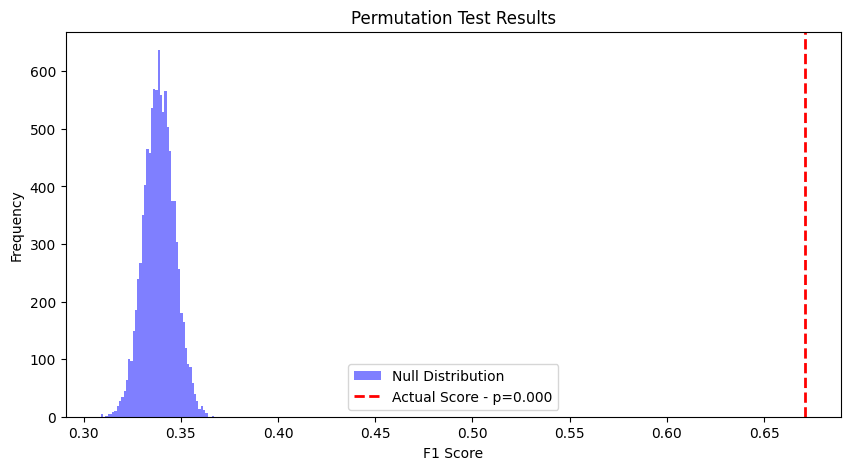

In [55]:

plt.figure(figsize=(10, 5), facecolor="w")
plt.hist(null_distribution, bins=50, alpha=0.5, label='Null Distribution', color='blue')
plt.axvline(actual_score, color='red', linestyle='dashed', linewidth=2, label=f'Actual Score - p={p_value:.3f}')
plt.title('Permutation Test Results')
plt.xlabel('F1 Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [22]:
actual_score, null_distribution, p_value=permutation_test_accurate_targets(test_loader,first_spike_times,detection_window, N=1000)
print(f"Actual Score: {actual_score:.4f} | Null Distribution Mean: {np.mean(null_distribution):.4f} | P-Value: {p_value:.4f}")

Actual Score: 0.6712 | Null Distribution Mean: 0.5104 | P-Value: 0.0000


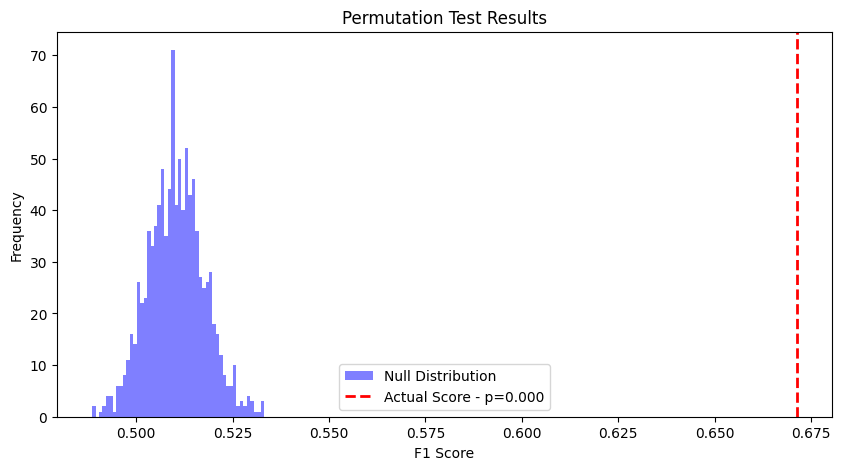

In [23]:

plt.figure(figsize=(10, 5), facecolor="w")
plt.hist(null_distribution, bins=50, alpha=0.5, label='Null Distribution', color='blue')
plt.axvline(actual_score, color='red', linestyle='dashed', linewidth=2, label=f'Actual Score - p={p_value:.3f}')
plt.title('Permutation Test Results')
plt.xlabel('F1 Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()